# Grammar Scoring Engine for Spoken English

SHL Hiring Assessment 2026

## Summary

**Task.** Given a 45 to 60 second recording of a spoken answer, predict its grammar score: a mean opinion score from 0 to 5 in steps of 0.5, given by human raters. There are 769 scored training clips and 216 test clips.

**Approach.** Grammar is a property of what the speaker says, so the engine needs models that understand speech, and 769 clips are far too few to train one. I keep three large pretrained models frozen, use them only to turn each clip into numbers, and train one small regressor on each:

| | What it captures | Frozen model and features | Regressor |
|---|---|---|---|
| 1 | The spoken content, as an audio language model understands it | Voxtral-Mini-3B listens to the clip; average hidden state over the audio tokens (3,072 numbers) | Ridge regression |
| 2 | How the speech sounds: fluency, rhythm, pronunciation | WavLM-large, layer 20, averaged over time (1,024 numbers) | SVR with an RBF kernel |
| 3 | Explicit, readable grammar evidence from the transcript | Whisper large-v3 transcript, then an LLM rubric score, the rate of grammar corrections, pause statistics and syntax statistics (123 features) | LightGBM |

A linear blend with non-negative weights combines the three predictions. Clips in which no speech is detected get the score 0 by a rule.

**Validation.** Two thirds of the training clips come from a speaker who has two or three answers in the training set, and one speaker's answers get nearly the same score. The test speakers are new. So every cross-validated score below holds out all clips of a speaker together (5 folds, repeated 3 times). With ordinary random folds the blend would look 0.03 RMSE better than it really is, and the WavLM model 0.05 better (sections 5 and 7).

**Results on the training data.**

| | RMSE | Pearson |
|---|---|---|
| **Training RMSE** (in-sample: the models are scored on the clips they were fitted on) | **0.180** | 0.989 |
| Cross-validated on unseen speakers, all 769 clips | **0.493** | 0.917 |
| Cross-validated on unseen speakers, the 732 clips with a score of 1 to 5 | 0.505 | 0.867 |

The in-sample number is required by the task statement, but it is optimistic by construction. The cross-validated numbers are the honest estimate of how the engine scores a new speaker.

**Contents.** 1 Setup · 2 Data · 3 Preprocessing and features · 4 Clips without speech · 5 Validation on unseen speakers · 6 The three models · 7 Blend · 8 Evaluation · 9 What the text model uses · 10 Submission

## 1. Setup

The heavy steps (speech recognition and the forward passes of the pretrained models) need a GPU and were run once on Kaggle's free T4 GPUs with the scripts in `extraction/`. They save a small `features/` folder. This notebook starts from that folder and runs on a CPU in under a minute. The README lists the commands for the whole chain.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from scipy.sparse.csgraph import connected_components
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

DATA = Path("data")            # train.csv and test.csv from the competition
FEATURES = Path("features")    # written by extraction/build_features.py

# One look for all charts.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#e6e5e0", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE, "figure.dpi": 110,
    "font.size": 10, "text.color": INK, "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.titlepad": 10,
    "axes.edgecolor": GRID, "axes.spines.top": False, "axes.spines.right": False, "axes.axisbelow": True,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "xtick.major.size": 0, "ytick.major.size": 0,
    "legend.frameon": False,
})
pd.set_option("display.precision", 3)

## 2. Data

In [2]:
train = pd.read_csv(DATA / "train.csv")        # filename, label
test = pd.read_csv(DATA / "test.csv")          # filename
meta = pd.read_csv(FEATURES / "meta.csv")      # one row per clip, training clips first, then test clips
assert list(meta.filename) == list(train.filename) + list(test.filename)

n_train = len(train)
y = train.label.values
duration = meta.duration.values
graded = y > 0                                  # clips with a real grammar score (1 to 5)

print(f"training clips: {n_train}   test clips: {len(test)}")
print(f"scores: {np.sort(train.label.unique())}")
print(f"mean score {y.mean():.2f}; clips with score 0: {(~graded).sum()}; mean score of the others: {y[graded].mean():.2f}")

training clips: 769   test clips: 216
scores: [0.  1.  1.5 2.  2.5 3.  3.5 4.  4.5 5. ]
mean score 3.31; clips with score 0: 37; mean score of the others: 3.48


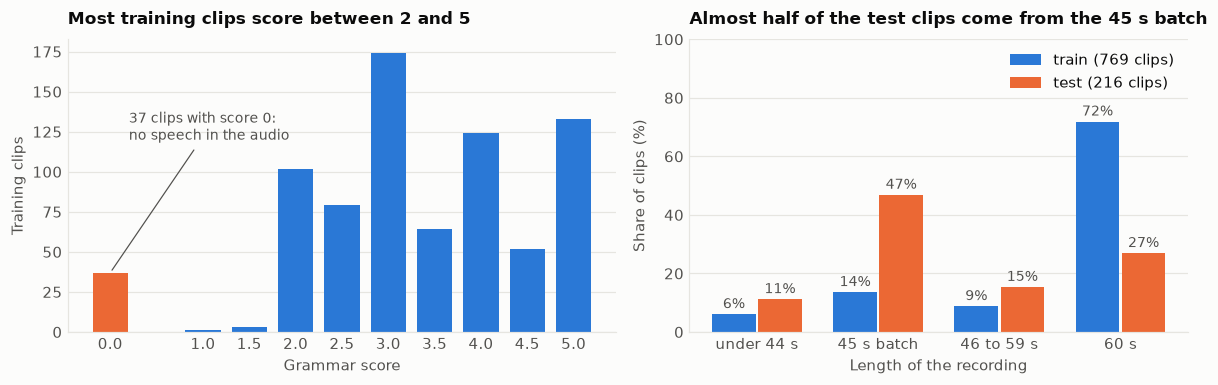

,training clips,mean score
under 44 s,45,3.367
45 s batch,103,2.922
46 to 59 s,63,3.659
60 s,521,3.580


In [3]:
def length_group(d):
    """Recording length groups. A large batch of clips is exactly 45.06 s long."""
    return np.select([d < 44, np.abs(d - 45.06) < 0.1, d < 59], ["under 44 s", "45 s batch", "46 to 59 s"], "60 s")

GROUPS = ["under 44 s", "45 s batch", "46 to 59 s", "60 s"]
group = length_group(duration)
share = pd.DataFrame({"train": pd.Series(group[:n_train]).value_counts(normalize=True),
                      "test": pd.Series(group[n_train:]).value_counts(normalize=True)}).reindex(GROUPS).fillna(0) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6), gridspec_kw={"width_ratios": [1.1, 1]})

counts = train.label.value_counts().sort_index()
ax1.bar(counts.index, counts.values, width=0.38, color=[ORANGE if s == 0 else BLUE for s in counts.index])
ax1.annotate(f"{counts.loc[0.0]} clips with score 0:\nno speech in the audio", xy=(0, counts.loc[0.0]), xytext=(0.2, 120),
             color=MUTED, fontsize=9, arrowprops={"arrowstyle": "-", "color": MUTED, "lw": 0.8})
ax1.set(title="Most training clips score between 2 and 5", xlabel="Grammar score", ylabel="Training clips")
ax1.set_xticks(counts.index)
ax1.grid(axis="x", visible=False)

x = np.arange(len(GROUPS))
for i, (col, color) in enumerate((("train", BLUE), ("test", ORANGE))):
    bars = ax2.bar(x + (i - 0.5) * 0.38, share[col], width=0.36, color=color, label=f"{col} ({(n_train, len(test))[i]} clips)")
    ax2.bar_label(bars, fmt="%.0f%%", padding=2, fontsize=9, color=MUTED)
ax2.set(title="Almost half of the test clips come from the 45 s batch", xlabel="Length of the recording",
        ylabel="Share of clips (%)", ylim=(0, 100))
ax2.set_xticks(x, GROUPS)
ax2.grid(axis="x", visible=False)
ax2.legend()
plt.tight_layout()
plt.show()

by_group = pd.DataFrame({"training clips": pd.Series(group[:n_train][graded]).value_counts(),
                         "mean score": pd.Series(y[graded]).groupby(group[:n_train][graded]).mean()}).reindex(GROUPS)
by_group

Three facts shape the rest of the design:

- **Scores are coarse and uneven.** They are mean opinion scores on a grid of 0.5, and scores below 2 are rare.
- **37 clips have the score 0**, which is outside the rubric (1 to 5). Section 4 shows that these clips contain no speech.
- **The test set is a different mix of recordings.** A batch of clips that are exactly 45.06 s long makes up 14% of the training set but 47% of the test set, and that batch scores lower on average. The model must work on those clips in particular, so I report results for them separately in section 8.

## 3. Preprocessing and features

All clips are 16 kHz mono WAV files, the input format of every model used here, so the audio itself needs no resampling or cleaning. Each clip goes through these steps (scripts in `extraction/`):

| Step | Script | Pretrained model | What is saved for each clip |
|---|---|---|---|
| Transcribe | `transcribe.py` | Whisper large-v3 | Two transcripts with word timestamps and confidences: a word-for-word one (the prompt asks Whisper to keep fillers and false starts) and a default one |
| Speech check, acoustic states | `audio_features.py` | wav2vec2-large (CTC), WavLM-large | Share of audio frames in which the CTC model hears no speech sound; average hidden state of every WavLM layer |
| Audio language model states | `voxtral_features.py` | Voxtral-Mini-3B | Average hidden state over the audio tokens, language-model layers 6 to 18 |
| LLM grammar features | `llm_features.py` | Qwen3.5-9B (open weights, served with vLLM) | Rubric score with a probability for each of 1 to 5; a minimally corrected transcript and the rate of edits it needed |
| Fluency features | `fluency_features.py` | none | Pauses, speech rate, fillers, repetitions, recognition confidence |
| Syntax features | `syntax_features.py` | spaCy | Sentence and clause complexity, agreement errors, part-of-speech ratios, word rarity |
| Assemble | `build_features.py` | | The `features/` folder loaded below |

```
                      ┌──────────────────────────────┐   ┌───────────┐
                 ┌──► │ Voxtral-Mini-3B (audio LLM)  │──►│ Ridge     │──┐
                 │    │ average state of audio tokens│   └───────────┘  │
                 │    └──────────────────────────────┘                  │
┌────────────┐   │    ┌──────────────────────────────┐   ┌───────────┐  │   ┌──────────────┐
│ audio clip │───┼──► │ WavLM-large, layer 20        │──►│ SVR (RBF) │──┼──►│ non-negative │──► grammar score
│ 16 kHz     │   │    │ average over time            │   └───────────┘  │   │ linear blend │    (1 to 5)
└────────────┘   │    └──────────────────────────────┘                  │   └──────────────┘
                 │    ┌──────────────────────────────┐   ┌───────────┐  │
                 ├──► │ Whisper large-v3 transcript  │──►│ LightGBM  │──┘
                 │    │ then 123 grammar features    │   └───────────┘
                 │    └──────────────────────────────┘
                 │    ┌──────────────────────────────┐
                 └──► │ wav2vec2 CTC: any speech?    │──► if not: score 0
                      └──────────────────────────────┘
```

**Why these three views.**

1. *Voxtral* is a language model that takes audio directly. Its middle layers encode what was said without first forcing the speech into a transcript, so grammatical slips that a speech recogniser tends to tidy up can survive. The clip is given with the instruction "How accurate and complex is the speaker's grammar?", and I average the hidden states at the positions of the audio tokens (padding excluded).
2. *WavLM* encodes how the speech sounds. Raters hear hesitation, rhythm and pronunciation together with grammar, and these are strongly related to language proficiency.
3. *The text features* measure grammar explicitly and can be inspected. The two most direct ones are the LLM rubric score (the model reads the transcript with the official rubric and I take the probability-weighted average of its answer 1 to 5, which gives a continuous score) and the edit rate (the LLM corrects the transcript with minimal changes; more edits per 100 words means more errors).

Which layer to use (WavLM 20; Voxtral 12 to 14, averaged) was chosen by the cross-validation described in section 5.

In [4]:
voxtral = np.load(FEATURES / "voxtral.npy")                     # [clips, 3072]
wavlm = np.load(FEATURES / "wavlm.npy")                         # [clips, 1024]
text = pd.read_parquet(FEATURES / "text_features.parquet").drop(columns=["split", "filename"])

FAMILIES = {   # the text features, grouped by what they measure
    "LLM rubric score": [c for c in text if c.startswith("judge_")],
    "Grammar-correction edit rates": [c for c in text if c.startswith("gec_")],
    "Fluency and timing": ["n_words_per_min", "too_few_words", "speech_span_ratio", "lead_silence", "speech_rate_wps",
                           "pauses_0.25_per_min", "pauses_0.5_per_min", "pauses_1.0_per_min", "mean_pause_s", "pause_time_ratio",
                           "mean_len_run", "articulation_rate", "filler_per_100w", "repeat_per_100w", "bigram_repeat_per_100w",
                           "type_token_ratio_50"],
    "Recognition confidence": ["lang_prob_en", "lang_prob_en_2nd", "lang_is_en", "word_prob_mean", "word_prob_p10",
                               "word_prob_lt05", "seg_logprob_mean", "seg_logprob_min", "no_speech_mean", "compression_mean"],
    "Syntax of the transcript": [c for c in text if c.startswith("syn_")],
    "Syntax of the corrected transcript": [c for c in text if c.startswith("sync_")],
}
assert sorted(sum(FAMILIES.values(), [])) == sorted(text.columns)

print(f"Voxtral states {voxtral.shape}, WavLM states {wavlm.shape}, text features {text.shape}")
pd.Series({k: len(v) for k, v in FAMILIES.items()}, name="number of features").to_frame()

Voxtral states (985, 3072), WavLM states (985, 1024), text features (985, 123)


,number of features
LLM rubric score,12
Grammar-correction edit rates,5
Fluency and timing,16
Recognition confidence,10
Syntax of the transcript,40
Syntax of the corrected transcript,40


## 4. Clips without speech

The wav2vec2 CTC model labels every 20 ms frame with a letter or with "blank" (no speech sound). In every clip scored 1 to 5, at most 95% of the frames are blank. In the 37 clips with score 0, at least 97% are: they contain noise, not speech. Whisper still writes a fluent "transcript" for them, so a text model alone would give them a normal score.

A regressor should not learn the grammar scale from clips without language, so I treat them with a rule: if the blank share is 0.96 or more, the score is 0. The regressors are trained only on the 732 clips scored 1 to 5.

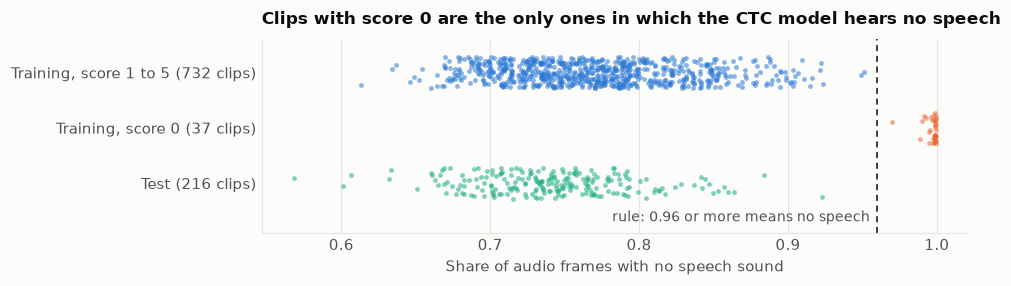

training: rule fires on 37 clips, 37 of them have score 0 (largest value among scored clips 0.951, smallest among score-0 clips 0.970)
test: rule fires on 0 clips (largest value 0.923)


In [5]:
NO_SPEECH_THRESHOLD = 0.96
blank = meta.ctc_blank_frac.values
no_speech = blank >= NO_SPEECH_THRESHOLD

rows = [("Training, score 1 to 5", blank[:n_train][graded], BLUE),
        ("Training, score 0", blank[:n_train][~graded], ORANGE),
        ("Test", blank[n_train:], AQUA)]
rng = np.random.default_rng(0)
fig, ax = plt.subplots(figsize=(9, 2.7))
for i, (name, values, color) in enumerate(rows):
    ax.scatter(values, i + rng.uniform(-0.28, 0.28, len(values)), s=10, color=color, alpha=0.55, linewidths=0)
ax.axvline(NO_SPEECH_THRESHOLD, color=INK, lw=1, ls=(0, (4, 3)))
ax.text(NO_SPEECH_THRESHOLD - 0.005, 2.62, "rule: 0.96 or more means no speech", ha="right", va="center", fontsize=9, color=MUTED)
ax.set_yticks(range(len(rows)), [f"{name} ({len(values)} clips)" for name, values, _ in rows])
ax.set(title="Clips with score 0 are the only ones in which the CTC model hears no speech",
       xlabel="Share of audio frames with no speech sound", ylim=(2.9, -0.6))
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

print(f"training: rule fires on {no_speech[:n_train].sum()} clips, {(no_speech[:n_train] & ~graded).sum()} of them have score 0 "
      f"(largest value among scored clips {blank[:n_train][graded].max():.3f}, smallest among score-0 clips {blank[:n_train][~graded].min():.3f})")
print(f"test: rule fires on {no_speech[n_train:].sum()} clips (largest value {blank[n_train:].max():.3f})")

## 5. Validation on unseen speakers

The data has no speaker labels, but the voices give the structure away. I describe each clip's voice with the early WavLM layers (3 and 6, which carry speaker identity rather than content) and compare clips by cosine similarity.

- For a **test** clip, the most similar training clip is a different person. Those similarities show how alike two different speakers can sound.
- For most **training** clips, the most similar other training clip is far more alike than that: it is the same person answering another question.

Two training clips are linked when they are more similar than 99.5% of the test clips are to their nearest training clip, and linked clips form one speaker.

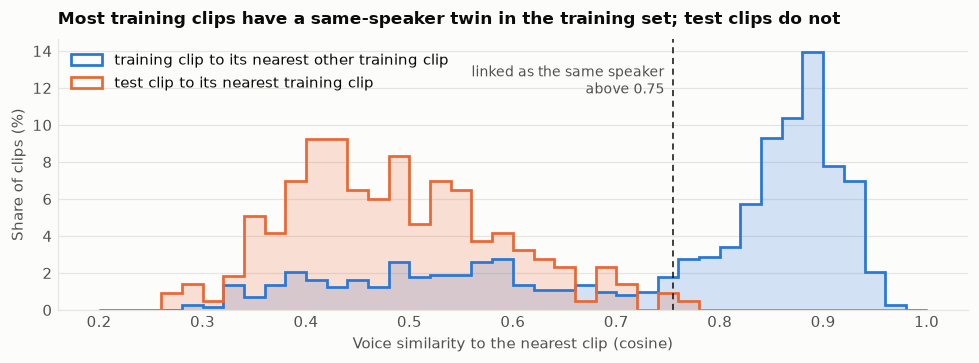

speakers among the 732 scored clips: 436; clips per speaker: 1 clip: 251, 2 clips: 79, 3 clips: 104, 5 clips: 1, 6 clips: 1
scored clips that have another clip of the same speaker: 66%
spread of scores: 1.01 over all clips, 0.21 between clips of the same speaker


In [6]:
voice = np.load(FEATURES / "voice.npy").astype(np.float32)       # WavLM layers 3 and 6: mean and std over time
voice = (voice - voice.mean(0)) / voice.std(0)
voice /= np.linalg.norm(voice, axis=1, keepdims=True)            # unit length, so a dot product is a cosine similarity

sim_train = voice[:n_train] @ voice[:n_train].T
np.fill_diagonal(sim_train, -1)                                  # a clip is not its own neighbour
nearest_train = sim_train.max(1)                                 # most similar other training clip
nearest_test = (voice[n_train:] @ voice[:n_train].T).max(1)      # most similar training clip, for every test clip

same_speaker = np.percentile(nearest_test, 99.5)
n_speakers, speaker = connected_components(sim_train > same_speaker, directed=False)

bins = np.linspace(0.2, 1.0, 41)
fig, ax = plt.subplots(figsize=(9, 3.4))
for values, color, label in ((nearest_train[graded], BLUE, "training clip to its nearest other training clip"),
                             (nearest_test, ORANGE, "test clip to its nearest training clip")):
    weights = np.full(len(values), 100 / len(values))
    ax.hist(values, bins=bins, weights=weights, color=color, alpha=0.2)
    ax.hist(values, bins=bins, weights=weights, color=color, histtype="step", linewidth=1.8, label=label)
ax.axvline(same_speaker, color=INK, lw=1, ls=(0, (4, 3)))
ax.text(same_speaker - 0.008, ax.get_ylim()[1] * 0.8, f"linked as the same speaker\nabove {same_speaker:.2f}", ha="right",
        fontsize=9, color=MUTED)
ax.set(title="Most training clips have a same-speaker twin in the training set; test clips do not",
       xlabel="Voice similarity to the nearest clip (cosine)", ylabel="Share of clips (%)")
ax.grid(axis="x", visible=False)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

sp = pd.DataFrame({"speaker": speaker, "score": y})[graded]
sizes = sp.speaker.value_counts()
within = sp.groupby("speaker").score.std().dropna().mean()
print(f"speakers among the {graded.sum()} scored clips: {len(sizes)}; clips per speaker: "
      + ", ".join(f"{k} clip{'s' if k > 1 else ''}: {v}" for k, v in sizes.value_counts().sort_index().items()))
print(f"scored clips that have another clip of the same speaker: {(sizes[sp.speaker].values > 1).mean():.0%}")
print(f"spread of scores: {sp.score.std():.2f} over all clips, {within:.2f} between clips of the same speaker")

A speaker's answers get almost the same score. If one answer is in the training folds and another in the validation fold, a model can recognise the voice and repeat the score, which says nothing about a new speaker. So the folds keep each speaker together (`StratifiedGroupKFold`, also balanced by score). I build ordinary random folds as well, only to measure how much they would flatter the models.

In [7]:
N_REPEATS, N_FOLDS = 3, 5
strata = np.where((y >= 0.5) & (y <= 2.0), 2.0, y).astype(str)   # the rare scores below 2 share a stratum with 2.0


def make_folds(by_speaker):
    """Fold number of every training clip, for each repeat."""
    folds = np.zeros((N_REPEATS, n_train), dtype=int)
    for repeat in range(N_REPEATS):
        if by_speaker:
            splits = StratifiedGroupKFold(N_FOLDS, shuffle=True, random_state=repeat).split(train, strata, groups=speaker)
        else:
            splits = StratifiedKFold(N_FOLDS, shuffle=True, random_state=repeat).split(train, strata)
        for k, (_, val) in enumerate(splits):
            folds[repeat, val] = k
    return folds


folds = make_folds(by_speaker=True)            # used for everything below
folds_random = make_folds(by_speaker=False)    # only for the comparison in section 7

shared = [np.mean([np.isin(speaker[f == k], speaker[f != k]).mean() for k in range(N_FOLDS)]) for f in (folds[0], folds_random[0])]
print(f"validation clips whose speaker is also in the training folds: {shared[0]:.0%} with speaker folds, {shared[1]:.0%} with random folds")

validation clips whose speaker is also in the training folds: 0% with speaker folds, 59% with random folds

## 6. The three models

Each model is cross-validated in the same way. A training clip is always predicted by a model that was fitted without that clip and without its speaker ("out-of-fold" prediction); the three repeats are averaged. The test clips are predicted by all 15 fitted models and averaged.

- **Ridge on the Voxtral states.** 3,072 inputs and 732 clips call for a linear model with strong shrinkage; the strength is picked inside each fit by leave-one-out validation (`RidgeCV`).
- **SVR on the WavLM states.** An RBF kernel compares each clip with similar-sounding training clips. C, epsilon and the kernel width were tuned by cross-validation; gamma is half of scikit-learn's default.
- **LightGBM on the text features.** Trees handle the mixed scales, the missing values and the interactions between features (an edit rate means something different for a 20-word answer than for a 120-word one). Small trees and a low learning rate, not tuned further.

In [8]:
def cross_validate(make_model, X, folds):
    """Out-of-fold predictions for the training clips and averaged predictions for the test clips."""
    X_train, X_test = X[:n_train], X[n_train:]
    oof = np.zeros((N_REPEATS, n_train))
    test_preds = []
    for repeat in range(N_REPEATS):
        for k in range(N_FOLDS):
            fit = (folds[repeat] != k) & graded          # fit on scored clips outside fold k
            val = folds[repeat] == k
            model = make_model().fit(X_train[fit], y[fit])
            oof[repeat, val] = model.predict(X_train[val])
            test_preds.append(model.predict(X_test))
    return np.clip(oof.mean(0), 1, 5), np.clip(np.mean(test_preds, axis=0), 1, 5)


def rmse(truth, pred):
    return float(np.sqrt(np.mean((truth - pred) ** 2)))


def scores(pred, mask=graded):
    return {"RMSE": rmse(y[mask], pred[mask]), "Pearson": pearsonr(y[mask], pred[mask])[0]}


MODELS = {
    "Voxtral + Ridge": (voxtral, lambda: make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-1, 5, 13)))),
    "WavLM + SVR": (wavlm, lambda: make_pipeline(StandardScaler(), SVR(C=10, epsilon=0.1, gamma=0.5 / wavlm.shape[1]))),
    "Text features + LightGBM": (text.values, lambda: LGBMRegressor(
        n_estimators=400, learning_rate=0.03, num_leaves=15, min_child_samples=20, subsample=0.8, subsample_freq=1,
        colsample_bytree=0.8, reg_lambda=1.0, random_state=0, verbose=-1)),
}

oof, test_pred, oof_random = {}, {}, {}
for name, (X, make_model) in MODELS.items():
    oof[name], test_pred[name] = cross_validate(make_model, X, folds)
    oof_random[name], _ = cross_validate(make_model, X, folds_random)

single = pd.DataFrame({name: scores(oof[name]) for name in MODELS}).T
single.loc["Baseline: always predict the mean score"] = {"RMSE": y[graded].std(), "Pearson": np.nan}
single

,RMSE,Pearson
Voxtral + Ridge,0.535,0.850
WavLM + SVR,0.566,0.831
Text features + LightGBM,0.608,0.800
Baseline: always predict the mean score,1.014,NaN


## 7. Blend

The three predictions are combined by a linear regression with non-negative weights, fitted on the out-of-fold predictions. Non-negative weights keep the blend easy to read: it can only average the models, never use one to cancel another.

The blend's own score must not use a clip's score to set the weights that predict it, so for scoring the weights are fitted inside each fold as well (`blend_cv`). The final weights, used for the test set, are fitted on all scored clips.

In [9]:
def blend_cv(P, folds):
    """Honest blend predictions: weights are fitted on the other folds."""
    out = np.zeros((N_REPEATS, n_train))
    for repeat in range(N_REPEATS):
        for k in range(N_FOLDS):
            fit, val = (folds[repeat] != k) & graded, folds[repeat] == k
            out[repeat, val] = LinearRegression(positive=True).fit(P[fit], y[fit]).predict(P[val])
    return np.clip(out.mean(0), 1, 5)


names = list(MODELS)
P_oof = np.column_stack([oof[n] for n in names])
P_test = np.column_stack([test_pred[n] for n in names])

blend_oof = blend_cv(P_oof, folds)
blend_oof_random = blend_cv(np.column_stack([oof_random[n] for n in names]), folds_random)

blender = LinearRegression(positive=True).fit(P_oof[graded], y[graded])       # final weights
print("blend: score = " + " + ".join(f"{w:.2f} x [{n}]" for n, w in zip(names, blender.coef_)) + f" {blender.intercept_:+.2f}")

# Does every model add something? Blend of each subset, scored the same way.
subsets = [[0], [1], [2], [0, 1], [0, 2], [1, 2], [0, 1, 2]]
ablation = pd.DataFrame([{"models in the blend": " + ".join(names[i].split(" + ")[0] for i in s),
                          **scores(blend_cv(P_oof[:, s], folds))} for s in subsets]).set_index("models in the blend")
ablation

blend: score = 0.48 x [Voxtral + Ridge] + 0.39 x [WavLM + SVR] + 0.26 x [Text features + LightGBM] -0.44


,RMSE,Pearson
models in the blend,,
Voxtral,0.535,0.850
WavLM,0.565,0.830
Text features,0.609,0.799
Voxtral + WavLM,0.515,0.861
Voxtral + Text features,0.522,0.857
WavLM + Text features,0.523,0.856
Voxtral + WavLM + Text features,0.505,0.867


Every pair is better than its single models and all three together are best, so each view contributes information the others lack. (The single-model rows also pass through the blend step, so they differ in the third decimal from section 6.) The weights sum to more than 1 with a negative constant: out-of-fold predictions are pulled towards the mean score, and the blend stretches them back out.

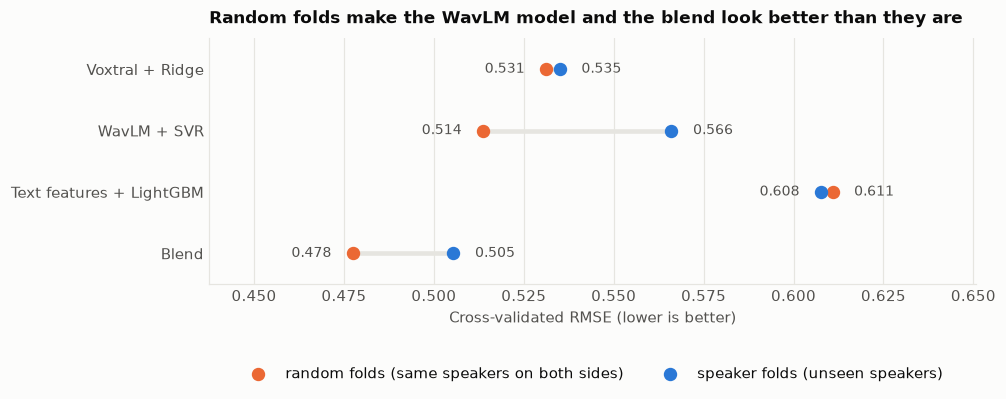

In [10]:
compare = pd.DataFrame({"speaker folds": {n: scores(oof[n])["RMSE"] for n in names} | {"Blend": scores(blend_oof)["RMSE"]},
                        "random folds": {n: scores(oof_random[n])["RMSE"] for n in names} | {"Blend": scores(blend_oof_random)["RMSE"]}})

fig, ax = plt.subplots(figsize=(9, 2.9))
rows_y = np.arange(len(compare))
ax.hlines(rows_y, compare["random folds"], compare["speaker folds"], color=GRID, lw=3, zorder=1)
ax.scatter(compare["random folds"], rows_y, s=60, color=ORANGE, zorder=2, label="random folds (same speakers on both sides)")
ax.scatter(compare["speaker folds"], rows_y, s=60, color=BLUE, zorder=2, label="speaker folds (unseen speakers)")
for i, (a, b) in enumerate(zip(compare["random folds"], compare["speaker folds"])):
    ax.text(min(a, b) - 0.006, i, f"{min(a, b):.3f}", ha="right", va="center", fontsize=9, color=MUTED)
    ax.text(max(a, b) + 0.006, i, f"{max(a, b):.3f}", ha="left", va="center", fontsize=9, color=MUTED)
ax.set_yticks(rows_y, compare.index)
ax.set(title="Random folds make the WavLM model and the blend look better than they are", xlabel="Cross-validated RMSE (lower is better)",
       ylim=(len(compare) - 0.5, -0.5), xlim=(compare.values.min() - 0.04, compare.values.max() + 0.04))
ax.grid(axis="y", visible=False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.28), ncols=2)
plt.show()

The WavLM model gains most from random folds: its acoustic states carry the voice, so it can recognise a speaker from the training folds and repeat that speaker's score. The Voxtral states and the text features say much less about who is speaking and barely change. The blend would look 0.03 better than it is. All other numbers in this notebook use the speaker folds.

## 8. Evaluation

The competition is scored on RMSE and Pearson correlation, so I report both.

The **training RMSE** is the error of the fitted pipeline on the clips it was fitted on: each model is refitted on all scored training clips, the blend weights from section 7 are applied, and the no-speech rule sets the score-0 clips. The **cross-validated** rows are the out-of-fold predictions from sections 6 and 7.

In [11]:
# In-sample predictions: fit on all scored training clips, predict the same clips.
fitted = {name: make_model().fit(X[:n_train][graded], y[graded]) for name, (X, make_model) in MODELS.items()}
P_insample = np.column_stack([np.clip(fitted[name].predict(MODELS[name][0][:n_train]), 1, 5) for name in names])
train_pred = np.where(no_speech[:n_train], 0.0, np.clip(blender.predict(P_insample), 1, 5))

cv_pred = np.where(no_speech[:n_train], 0.0, blend_oof)        # cross-validated prediction for every training clip
everyone = np.ones(n_train, dtype=bool)

results = pd.DataFrame({
    "Training (in-sample), all 769 clips": scores(train_pred, everyone),
    "Training (in-sample), 732 scored clips": scores(train_pred),
    "Cross-validated, unseen speakers, all 769 clips": scores(cv_pred, everyone),
    "Cross-validated, unseen speakers, 732 scored clips": scores(cv_pred),
}).T
print(f"TRAINING RMSE (in-sample, all {n_train} training clips): {results.RMSE.iloc[0]:.4f}")
print(f"Cross-validated RMSE on unseen speakers (all {n_train} training clips): {results.RMSE.iloc[2]:.4f}, "
      f"Pearson {results.Pearson.iloc[2]:.4f}")
results

TRAINING RMSE (in-sample, all 769 training clips): 0.1797
Cross-validated RMSE on unseen speakers (all 769 training clips): 0.4931, Pearson 0.9173


,RMSE,Pearson
"Training (in-sample), all 769 clips",0.180,0.989
"Training (in-sample), 732 scored clips",0.184,0.983
"Cross-validated, unseen speakers, all 769 clips",0.493,0.917
"Cross-validated, unseen speakers, 732 scored clips",0.505,0.867


The gap between the two is expected: the SVR and LightGBM fit their training clips closely. The cross-validated row is the one to trust. Including the 37 no-speech clips raises the correlation because the rule gets all of them exactly right; the 732 scored clips are the harder and more relevant test.

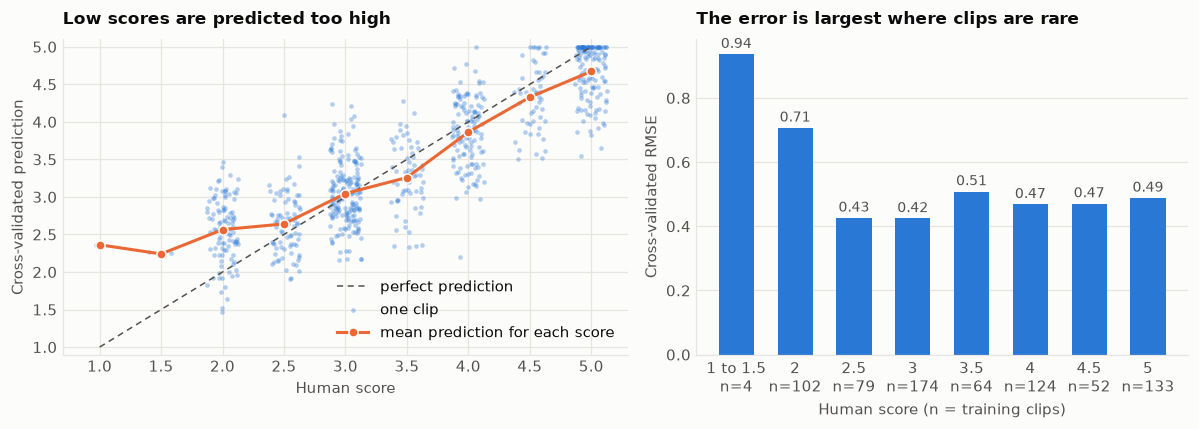

In [12]:
grades = np.sort(np.unique(y[graded]))
mean_pred = [blend_oof[y == g].mean() for g in grades]
# Error by score; the four clips scored 1 or 1.5 share one bar.
bands = [("1 to 1.5", (y >= 1) & (y <= 1.5))] + [(f"{g:g}", y == g) for g in grades if g >= 2]
band_rmse = [rmse(y[m], blend_oof[m]) for _, m in bands]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [1.15, 1]})
jitter = np.random.default_rng(0).uniform(-0.13, 0.13, graded.sum())
ax1.plot([1, 5], [1, 5], color=MUTED, lw=1, ls=(0, (4, 3)), label="perfect prediction")
ax1.scatter(y[graded] + jitter, blend_oof[graded], s=9, color=BLUE, alpha=0.35, linewidths=0, label="one clip")
ax1.plot(grades, mean_pred, color=ORANGE, lw=2, marker="o", ms=6, markeredgecolor=SURFACE, label="mean prediction for each score")
ax1.set(title="Low scores are predicted too high", xlabel="Human score", ylabel="Cross-validated prediction",
        xlim=(0.7, 5.3), ylim=(0.9, 5.1))
ax1.set_xticks(grades)
ax1.legend(loc="lower right")

bars = ax2.bar(np.arange(len(bands)), band_rmse, width=0.6, color=BLUE)
ax2.bar_label(bars, fmt="%.2f", padding=2, fontsize=9, color=MUTED)
ax2.set_xticks(np.arange(len(bands)), [f"{name}\nn={m.sum()}" for name, m in bands])
ax2.set(title="The error is largest where clips are rare", xlabel="Human score (n = training clips)", ylabel="Cross-validated RMSE")
ax2.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

In [13]:
batch = pd.DataFrame([{"recording length": g, "clips": int((graded & (group[:n_train] == g)).sum()),
                       "mean score": y[graded & (group[:n_train] == g)].mean(),
                       "mean prediction": blend_oof[graded & (group[:n_train] == g)].mean(),
                       **scores(blend_oof, graded & (group[:n_train] == g))} for g in GROUPS]).set_index("recording length")
batch

,clips,mean score,mean prediction,RMSE,Pearson
recording length,,,,,
under 44 s,45,3.367,3.439,0.547,0.776
45 s batch,103,2.922,3.033,0.513,0.784
46 to 59 s,63,3.659,3.655,0.458,0.896
60 s,521,3.580,3.543,0.506,0.870


**Reading the results.**

- The blend explains about three quarters of the variance in the human scores on speakers it has never heard (Pearson 0.87), with a typical error of half a score point. The scores themselves are human opinions on a grid of 0.5, so part of that error is rater disagreement that no model can remove.
- Errors are not uniform. Scores of 2.0 and below are predicted too high (a clip scored 2.0 gets 2.6 on average), and the engine is most accurate from 2.5 upwards. This "pull towards the middle" is the main remaining weakness.
- The 45 s batch, which makes up almost half of the test set, has about the same RMSE as the 60 s clips (0.51). Its predictions are 0.11 too high on average, because this batch contains more low scores.

## 9. What the text model uses

The text model is the readable part of the engine. LightGBM records how much each feature reduced the error ("gain"); summing the gain by feature family shows where its evidence comes from.

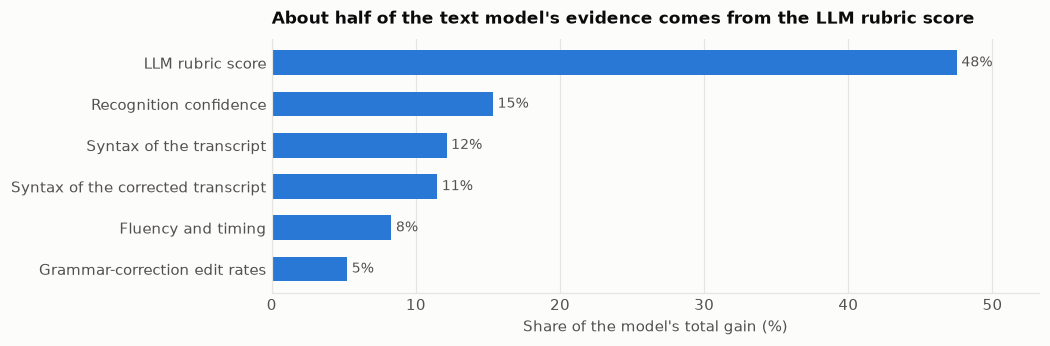

,share of gain (%),rank correlation with the human score
judge_disfluent_p2,12.364,-0.691
judge_clean,10.002,0.684
judge_disfluent_p4,8.430,0.689
lang_prob_en_2nd,7.948,0.466
judge_clean_p5,3.867,0.649
judge_disfluent,3.800,0.687
judge_clean_p2,3.594,-0.686
gec_edits_per_100w,2.683,-0.565
type_token_ratio_50,2.615,0.463
judge_clean_p4,2.347,0.690


In [14]:
gain = pd.Series(fitted["Text features + LightGBM"].booster_.feature_importance(importance_type="gain"), index=text.columns)
family_share = pd.Series({fam: gain[cols].sum() for fam, cols in FAMILIES.items()}).sort_values() / gain.sum() * 100

fig, ax = plt.subplots(figsize=(9, 3))
bars = ax.barh(family_share.index, family_share.values, height=0.6, color=BLUE)
ax.bar_label(bars, fmt="%.0f%%", padding=3, fontsize=9, color=MUTED)
ax.set(title="About half of the text model's evidence comes from the LLM rubric score",
       xlabel="Share of the model's total gain (%)", xlim=(0, family_share.max() * 1.12))
ax.grid(axis="y", visible=False)
plt.show()

top = gain.sort_values(ascending=False).head(10)
rho = [spearmanr(text[c][:n_train][graded], y[graded], nan_policy="omit")[0] for c in top.index]
pd.DataFrame({"share of gain (%)": top.values / gain.sum() * 100, "rank correlation with the human score": rho}, index=top.index)

Feature names: `judge_disfluent` and `judge_clean` are the LLM rubric scores on the word-for-word and the default transcript (`_p1` to `_p5` are the probabilities of each answer); `gec_*` count the edits the LLM needed to make the transcript grammatical, per 100 words; `type_token_ratio_50` is the share of distinct words in a 50-word window; `lang_prob_en_2nd` is Whisper's confidence that the second half of the clip is English.

The directions are the ones a human rater would expect: a higher rubric score and a more varied vocabulary go with higher human scores, more corrections per 100 words with lower ones. The edit rates add little on top of the rubric score because the two measure the same thing. `lang_prob_en_2nd` is a different kind of evidence: it reflects how clearly the speech is recognised as English, which is about pronunciation rather than grammar.

## 10. Submission

Test predictions: each model's 15 cross-validation fits are averaged, the final blend weights are applied, predictions are limited to the rubric range 1 to 5, and the no-speech rule is applied (it does not fire on any test clip).

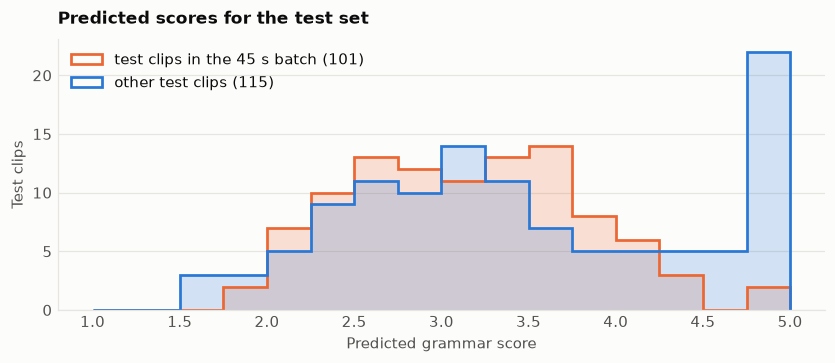

submission.csv: 216 rows, predictions from 1.66 to 5.00, mean 3.33


,training: mean score,test: mean prediction
other clips,3.572,3.481
45 s batch,2.922,3.154


In [15]:
final = np.clip(blender.predict(P_test), 1, 5)
final[no_speech[n_train:]] = 0.0
submission = pd.DataFrame({"filename": test.filename, "label": np.round(final, 4)})
submission.to_csv("submission.csv", index=False)

test_group = group[n_train:]
bins = np.linspace(1, 5, 17)
fig, ax = plt.subplots(figsize=(9, 3.2))
for values, color, label in ((final[test_group == "45 s batch"], ORANGE, "test clips in the 45 s batch"),
                             (final[test_group != "45 s batch"], BLUE, "other test clips")):
    ax.hist(values, bins=bins, color=color, alpha=0.2)
    ax.hist(values, bins=bins, color=color, histtype="step", linewidth=1.8, label=f"{label} ({len(values)})")
ax.set(title="Predicted scores for the test set", xlabel="Predicted grammar score", ylabel="Test clips")
ax.grid(axis="x", visible=False)
ax.legend(loc="upper left")
plt.show()

print(f"submission.csv: {len(submission)} rows, predictions from {final.min():.2f} to {final.max():.2f}, mean {final.mean():.2f}")
pd.DataFrame({"training: mean score": pd.Series(y[graded]).groupby(group[:n_train][graded] == "45 s batch").mean(),
              "test: mean prediction": pd.Series(final).groupby(test_group == "45 s batch").mean()}
             ).rename(index={True: "45 s batch", False: "other clips"})